## Cosine Similarity Calculations
Cosine similarity is a measure of similarity between two non-zero vectors of an inner product space that measures the cosine of the angle between them. Similarity measures have a multiude of uses in machine learning projects; they come in handy when matching strings, measuring distance, and extracting features. This similarity measurement is particularly concerned with orientation, rather than magnitude. 
In this case study, you'll use the cosine similarity to compare both a numeric data within a plane and a text dataset for string matching.

Load the Python modules, including cosine_similarity, from sklearn.metrics.pairwise

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
plt.style.use('ggplot')
from scipy import spatial
from sklearn.metrics.pairwise import cosine_similarity

**<font color='teal'> Load the distance dataset into a dataframe. </font>**

In [2]:
distance_df = pd.read_csv('distance_dataset (1).csv')
distance_df.head()

,Unnamed: 0,X,Y,Z,ClusterID
0,0,5.135779,4.167542,5.787635,4
1,1,4.280721,5.770909,6.091044,4
2,2,8.329098,7.540436,3.247239,2
3,3,5.470224,5.069249,5.768313,4
4,4,2.381797,2.402374,3.879101,1


### Cosine Similarity with clusters and numeric matrices

All points in our dataset can be thought of as feature vectors. We illustrate it here as we display the __Cosine Similarity__ between each feature vector in the YZ plane and the [5, 5] vector we chose as reference. The sklearn.metrics.pairwise module provides an efficient way to compute the __cosine_similarity__ for large arrays from which we can compute the similarity.

 **<font color='teal'> First, create a 2D and a 3D matrix from the dataframe. The 2D matrix should contain the 'Y' and 'Z' columns and the 3D matrix should contain the 'X','Y', and 'Z' columns.</font>**

In [3]:
matrix_2d = distance_df[['X', 'Y']].to_numpy()
print(matrix_2d[:5])

matrix_3d = distance_df[['X', 'Y', 'Z']].to_numpy()
print(matrix_3d[:5])

[[5.13577939 4.16754224]
 [4.2807207  5.77090875]
 [8.3290979  7.54043595]
 [5.47022447 5.06924901]
 [2.38179703 2.40237389]]
[[5.13577939 4.16754224 5.7876354 ]
 [4.2807207  5.77090875 6.0910442 ]
 [8.3290979  7.54043595 3.2472394 ]
 [5.47022447 5.06924901 5.76831344]
 [2.38179703 2.40237389 3.87910086]]


Calculate the cosine similarity for those matrices with reference planes of 5,5 and 5,5,5. Then subtract those measures from 1 in new features.

In [4]:
# compute cosine similarity between each row in matrix_3d and reference vector [5, 5, 5]
simCosine3D = 1. - cosine_similarity(matrix_3d, [[5, 5, 5]])

# compute cosine similarity between each row in matrix_2d and reference vector [5, 5]
simCosine2D = 1. - cosine_similarity(matrix_2d, [[5, 5]])

Using the 2D matrix and the reference plane of (5,5) we can use a scatter plot to view the way the similarity is calculated using the Cosine angle.

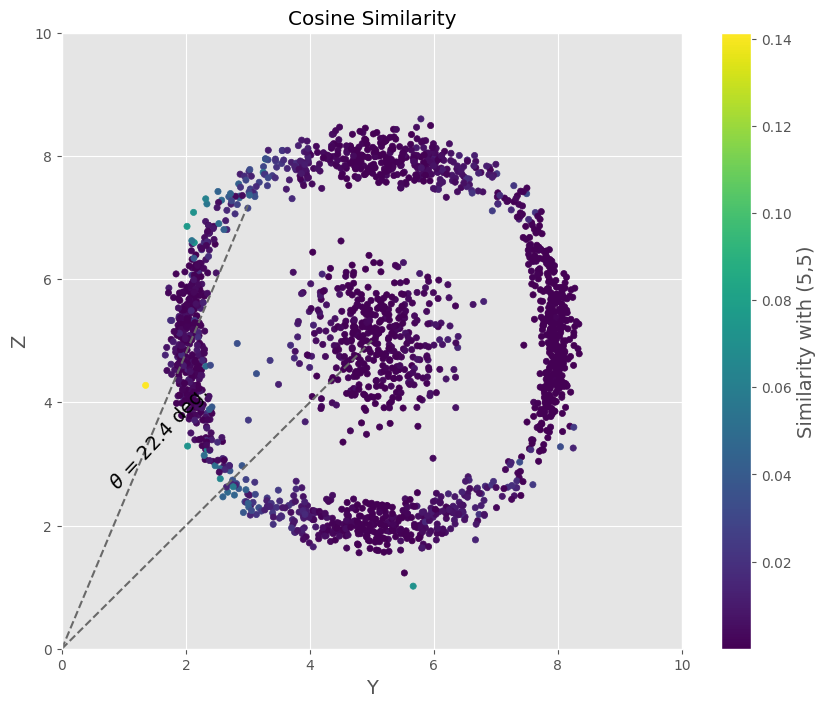

In [5]:
# Create new figure for 2D cosine similarity plot
figCosine = plt.figure(figsize=[10,8])

# Plot Y vs Z, colored by cosine similarity to (5,5)
plt.scatter(distance_df.Y, distance_df.Z, c=simCosine2D[:,0], s=20)

# Add reference lines
plt.plot([0,5],[0,5], '--', color='dimgray')
plt.plot([0,3],[0,7.2], '--', color='dimgray')

# Add annotation showing the angle θ between vectors
plt.text(0.7,2.6,r'$\theta$ = 22.4 deg.', rotation=47, size=14)

# Set plot limits and labels
plt.ylim([0,10])
plt.xlim([0,10])
plt.xlabel('Y', size=14)
plt.ylabel('Z', size=14)

# Add title and colorbar and set label for colorbar
plt.title('Cosine Similarity')
cb = plt.colorbar()
cb.set_label('Similarity with (5,5)', size=14)

# Save figure
figCosine.savefig('similarity-cosine.png')

Now, plot the 3D matrix with the similarity and the reference plane, (5,5,5).

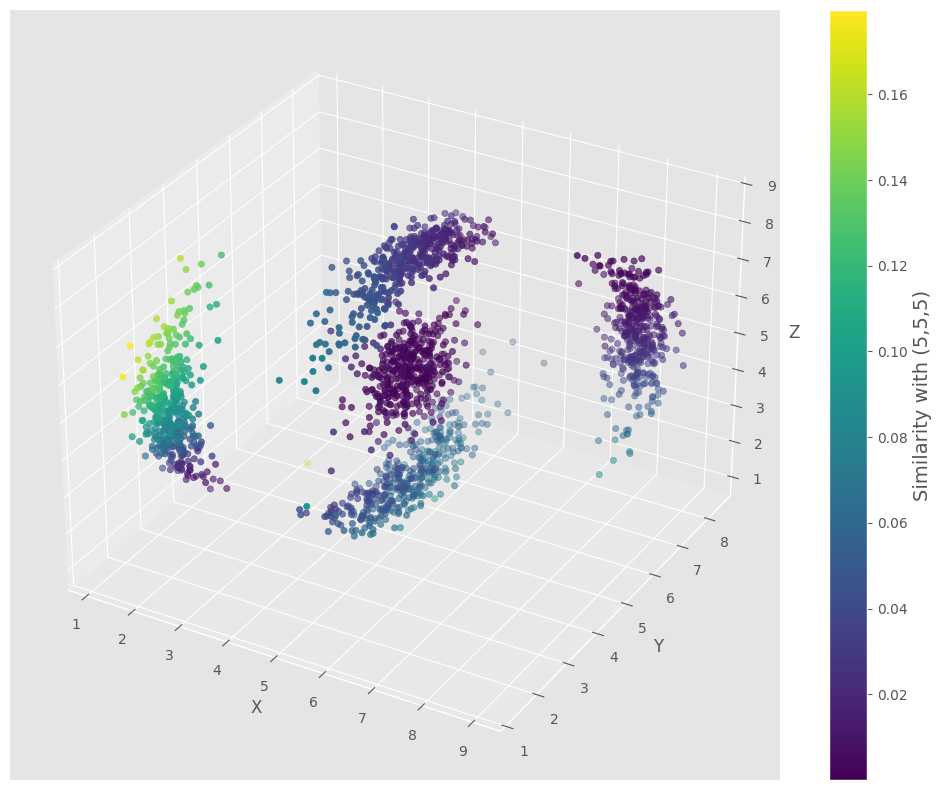

In [6]:
# Import 3D plotting tools for matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Create new figure for 3D cosine similarity plot
figCosine3D = plt.figure(figsize=(10, 8))

# Add 3D subplot to the figure
ax = figCosine3D.add_subplot(111, projection='3d')

# Plot each point in 3D space using X, Y, Z coordinates; color points by cosine similarity to reference vector (5, 5, 5)
p = ax.scatter(matrix_3d[:,0], matrix_3d[:,1], matrix_3d[:,2], c=simCosine3D[:,0])

# Label axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Add colorbar to show similarity scale and colorbar
cb = figCosine3D.colorbar(p)
cb.set_label('Similarity with (5,5,5)', size=14)

# Adjust layout
figCosine3D.tight_layout()

# Save plot as high-res PNG with transparent background
figCosine3D.savefig('cosine-3D.png', dpi=300, transparent=True)

----

### Cosine Similarity with text data
This is a quick example of how you can use Cosine Similarity to compare different text values or names for record matching or other natural language proecessing needs. 
First, we use count vectorizer to create a vector for each unique word in our Document 0 and Document 1. 

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
Document0 = "Starbucks Coffee"
Document1 = "Essence of Coffee"

corpus = [Document0, Document1]

X_train_counts = count_vect.fit_transform(corpus)

pd.DataFrame(X_train_counts.toarray(),
             columns=count_vect.get_feature_names_out(),
             index=['Document 0','Document 1'])


,coffee,essence,of,starbucks
Document 0,1,0,0,1
Document 1,1,1,1,0


Now, we use a common frequency tool called TF-IDF to convert the vectors to unique measures.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
trsfm = vectorizer.fit_transform(corpus)
pd.DataFrame(trsfm.toarray(),
             columns=vectorizer.get_feature_names_out(),
             index=['Document 0','Document 1'])

,coffee,essence,of,starbucks
Document 0,0.579739,0.000000,0.000000,0.814802
Document 1,0.449436,0.631667,0.631667,0.000000


Here, we finally apply the __Cosine Similarity__ measure to calculate how similar Document 0 is compared to any other document in the corpus. Therefore, the first value of 1 is showing that the Document 0 is 100% similar to Document 0 and 0.26055576 is the similarity measure between Document 0 and Document 1.

In [9]:
cosine_similarity(trsfm[0:1], trsfm)

array([[1.        , 0.26055567]])

Replace the current values for `Document 0` and `Document 1` with your own sentence or paragraph and apply the same steps as we did in the above example.

 **<font color='teal'> Combine the documents into a corpus.</font>**

In [19]:
DocumentA = "You are my sunshine"
DocumentB = "My only sunshine"
DocumentC = "You make me happy"

corpus2 = [DocumentA, DocumentB, DocumentC]

 **<font color='teal'> Apply the count vectorizer to the corpus to transform it into vectors.</font>**

In [20]:
X_train_counts2 = count_vect.fit_transform(corpus2)

 **<font color='teal'> Convert the vector counts to a dataframe with Pandas.</font>**

In [21]:
pd.DataFrame(X_train_counts2.toarray(),
             columns=count_vect.get_feature_names_out(),
             index=['Document A','Document B', 'Document C'])

,are,happy,make,me,my,only,sunshine,you
Document A,1,0,0,0,1,0,1,1
Document B,0,0,0,0,1,1,1,0
Document C,0,1,1,1,0,0,0,1


 **<font color='teal'> Apply TF-IDF to convert the vectors to unique frequency measures.</font>**

In [22]:
trsfm2 = vectorizer.fit_transform(corpus2)
pd.DataFrame(trsfm2.toarray(),
             columns=vectorizer.get_feature_names_out(),
             index=['Document A','Document B', 'Document C'])

,are,happy,make,me,my,only,sunshine,you
Document A,0.604652,0.000000,0.000000,0.000000,0.459854,0.000000,0.459854,0.459854
Document B,0.000000,0.000000,0.000000,0.000000,0.517856,0.680919,0.517856,0.000000
Document C,0.000000,0.528635,0.528635,0.528635,0.000000,0.000000,0.000000,0.402040


 **<font color='teal'> Use the cosine similarity function to get measures of similarity for the sentences or paragraphs in your original document.</font>**

In [29]:
cosine_similarity(trsfm2, trsfm2)

array([[1.        , 0.47627592, 0.18487962],
       [0.47627592, 1.        , 0.        ],
       [0.18487962, 0.        , 1.        ]])